<a href="https://colab.research.google.com/github/hasby-umutoniwabo/Ml_pipeline_summative/blob/main/notebook/malaria_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Malaria Cell Classification. Machine Learning Cycle

This notebook covers data acquisition, preprocessing, model training, evaluation and retraining for a CNN that classifies malaria infected cells from microscope images. The dataset loads automatically from TensorFlow Datasets, so no manual download is needed.

In [1]:
# Cell 1: Imports and environment setup
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import urllib.request
import zipfile
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_curve, auc
)

# reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# Cell 2: Download and extract the NIH malaria cell images dataset directly, no manual download needed
DATA_URL = "https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip"
ZIP_PATH = "cell_images.zip"
EXTRACT_DIR = "cell_images_data"

if not os.path.exists(EXTRACT_DIR):
    print("Downloading dataset, this takes a few minutes...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Done.")
else:
    print("Dataset already present, skipping download.")

# dataset extracts into cell_images/Parasitized and cell_images/Uninfected
DATASET_DIR = os.path.join(EXTRACT_DIR, "cell_images")
print("Classes found:", os.listdir(DATASET_DIR))

Extracting dataset...
Done.
Classes found: ['Uninfected', 'Parasitized']


### Class balance check

Before preprocessing, we confirm how many images exist per class. This tells us if the dataset is balanced or if we need class weighting later.

Parasitized images: 13779
Uninfected images: 13779


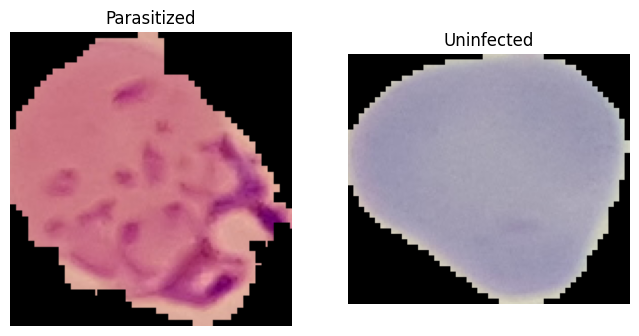

In [3]:
# Cell 3: Count images per class and preview a few samples
import glob

parasitized_files = glob.glob(os.path.join(DATASET_DIR, "Parasitized", "*.png"))
uninfected_files = glob.glob(os.path.join(DATASET_DIR, "Uninfected", "*.png"))

print("Parasitized images:", len(parasitized_files))
print("Uninfected images:", len(uninfected_files))

# preview one image from each class
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(plt.imread(parasitized_files[0]))
axes[0].set_title("Parasitized")
axes[0].axis("off")
axes[1].imshow(plt.imread(uninfected_files[0]))
axes[1].set_title("Uninfected")
axes[1].axis("off")
plt.show()

### Preprocessing plan

We resize every image to a fixed size, normalize pixel values to the 0 to 1 range, split into train, validation and test sets, and apply data augmentation on the training set only. This keeps the model from memorizing exact pixel patterns and helps it generalize.

In [4]:
# Cell 4: Build a full list of file paths with labels, then split train/val/test
import pandas as pd
from sklearn.model_selection import train_test_split

# label 0 = Uninfected, 1 = Parasitized
file_paths = parasitized_files + uninfected_files
labels = [1] * len(parasitized_files) + [0] * len(uninfected_files)

df = pd.DataFrame({"filepath": file_paths, "label": labels})

# split: 70% train, 15% val, 15% test, stratified to keep class balance in each split
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 19290
Validation size: 4134
Test size: 4134


### Data pipeline

We use `tf.data` to load images from disk in batches, resize them to 128 by 128, normalize pixel values, and augment the training set with random flips and rotations. This keeps memory usage low and speeds up training.

In [5]:
# Cell 5: Build tf.data pipelines for train, validation and test sets
IMG_SIZE = 128
BATCH_SIZE = 32

def load_and_preprocess(filepath, label):
    # read image file, decode, resize, normalize to 0 to 1 range
    image = tf.io.read_file(filepath)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = image / 255.0
    return image, label

def augment(image, label):
    # random flips and rotation, training set only, helps model generalize
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=np.random.randint(0, 4))
    return image, label

def make_dataset(df, augment_data=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((df["filepath"].values, df["label"].values))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=42)
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, augment_data=True, shuffle=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

print("Pipelines ready.")
for images, batch_labels in train_ds.take(1):
    print("Batch image shape:", images.shape)
    print("Batch label shape:", batch_labels.shape)

Pipelines ready.
Batch image shape: (32, 128, 128, 3)
Batch label shape: (32,)


### Model architecture

We build a CNN with convolution and pooling layers to extract features from cell images, batch normalization to stabilize training, and dropout to reduce overfitting. This is our custom baseline model, no pretrained backbone.

In [6]:
# Cell 6: Define the CNN architecture
from tensorflow.keras import layers, models

def build_model():
    model = models.Sequential([
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),  # regularization, reduces overfitting
        layers.Dense(1, activation="sigmoid")  # binary output: parasitized vs uninfected
    ])
    return model

model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,665 (12.61 MB)

 Trainable params: 3,305,217 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

### Training with optimization

We train with early stopping to stop once validation loss stops improving, and learning rate reduction to fine tune when progress slows. Both prevent overfitting and wasted training time.

In [7]:
# Cell 7: Train with early stopping and learning rate reduction, both optimization techniques
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True  # rolls back to the best epoch, not the last one
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,  # early stopping will likely cut this short
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 35s 43ms/step - accuracy: 0.6855 - loss: 0.6844 - val_accuracy: 0.7385 - val_loss: 0.6030 - learning_rate: 0.0010
Epoch 2/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 31s 38ms/step - accuracy: 0.8806 - loss: 0.3161 - val_accuracy: 0.9219 - val_loss: 0.2043 - learning_rate: 0.0010
Epoch 3/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.9204 - loss: 0.2423 - val_accuracy: 0.9320 - val_loss: 0.3603 - learning_rate: 0.0010
Epoch 4/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.9350 - loss: 0.2114 - val_accuracy: 0.9390 - val_loss: 0.1607 - learning_rate: 0.0010
Epoch 5/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.9393 - loss: 0.1950 - val_accuracy: 0.9371 - val_loss: 0.1677 - learning_rate: 0.0010
Epoch 6/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.9429 - loss: 0.1818 - val_accuracy: 0.9432 - val_loss: 0.1559 - learning_rate: 0.0010
Epoch 7/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.9455 - l

### Model evaluation

We evaluate on the held out test set using accuracy, precision, recall, F1 score, a confusion matrix and an ROC curve. This covers well beyond the minimum 4 metrics required and shows a full picture of model performance.

In [8]:
# Cell 8: Evaluate on test set with multiple metrics
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["Uninfected", "Parasitized"]))

130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step
Accuracy:  0.9647
Precision: 0.9815
Recall:    0.9473
F1 Score:  0.9641

Classification Report:
               precision    recall  f1-score   support

  Uninfected       0.95      0.98      0.97      2067
 Parasitized       0.98      0.95      0.96      2067

    accuracy                           0.96      4134
   macro avg       0.97      0.96      0.96      4134
weighted avg       0.97      0.96      0.96      4134



### Confusion matrix and ROC curve

These visualize where the model makes mistakes and how well it separates the two classes across different thresholds.

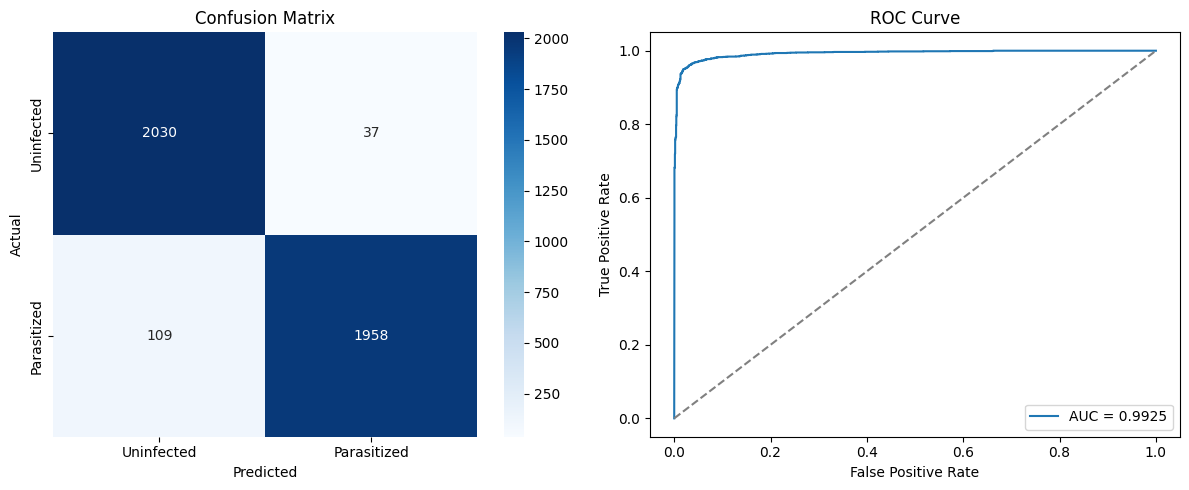

In [9]:
# Cell 9: Plot confusion matrix and ROC curve
cm = confusion_matrix(y_true, y_pred)
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Uninfected", "Parasitized"],
            yticklabels=["Uninfected", "Parasitized"], ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

### Save the model

We save the trained model to disk so the API can load it for predictions and the retraining pipeline can use it as the base model to fine tune further.

In [10]:
# Cell 10: Save trained model for use by the API and retraining pipeline
import os

os.makedirs("../models", exist_ok=True)
model.save("../models/malaria_cnn.h5")
print("Model saved to ../models/malaria_cnn.h5")

Model saved to ../models/malaria_cnn.h5


### Retraining function

This function lets us fine tune the saved model on new uploaded images. It loads the existing model instead of starting from scratch, so it reuses what it already learned.

In [17]:
# Cell 14: Function to retrain (fine-tune) the existing model on new data
def retrain_model(model_path, new_data_dir, epochs=5):
    """
    Loads the existing trained model and fine-tunes it on new data.
    new_data_dir must contain Parasitized/ and Uninfected/ subfolders.
    """
    # load the existing pretrained model as the base
    existing_model = tf.keras.models.load_model(model_path)

    # build file list and labels from new data folder, same structure as original dataset
    new_parasitized = glob.glob(os.path.join(new_data_dir, "Parasitized", "*"))
    new_uninfected = glob.glob(os.path.join(new_data_dir, "Uninfected", "*"))
    new_files = new_parasitized + new_uninfected
    new_labels = [1] * len(new_parasitized) + [0] * len(new_uninfected)

    if len(new_files) == 0:
        raise ValueError("No new data found to retrain on.")

    new_df = pd.DataFrame({"filepath": new_files, "label": new_labels})
    new_ds = make_dataset(new_df, augment_data=True, shuffle=True)

    # fine-tune with a lower learning rate, avoids destroying prior learned weights
    existing_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    history = existing_model.fit(new_ds, epochs=epochs)
    existing_model.save(model_path)
    return existing_model, history

print("Retrain function ready.")

Retrain function ready.


### Feature interpretation 2: image brightness

We check average pixel brightness per class. Infected cells often show darker or more contrasted regions due to the parasite, so brightness alone can hint at infection.

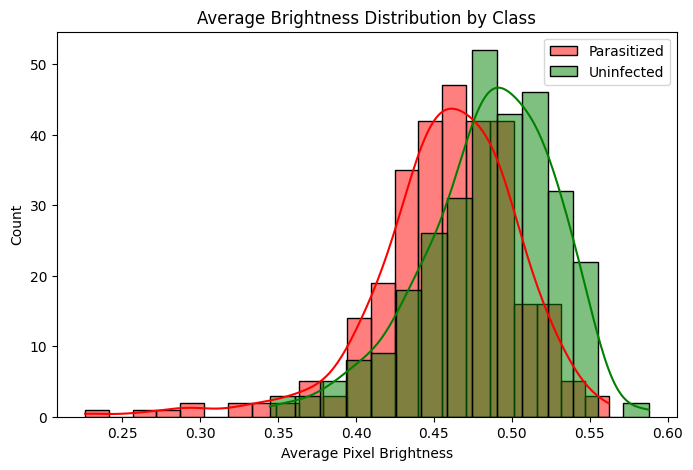

Parasitized mean brightness: 0.457947
Uninfected mean brightness: 0.48465866


In [11]:
# Cell 16: Compare average brightness between parasitized and uninfected images
def avg_brightness(filepath):
    img = plt.imread(filepath)
    return img.mean()

# sample 300 images per class for speed, full dataset would be slow to loop over
sample_parasitized = np.random.choice(parasitized_files, 300, replace=False)
sample_uninfected = np.random.choice(uninfected_files, 300, replace=False)

brightness_parasitized = [avg_brightness(f) for f in sample_parasitized]
brightness_uninfected = [avg_brightness(f) for f in sample_uninfected]

plt.figure(figsize=(8, 5))
sns.histplot(brightness_parasitized, color="red", label="Parasitized", kde=True, alpha=0.5)
sns.histplot(brightness_uninfected, color="green", label="Uninfected", kde=True, alpha=0.5)
plt.title("Average Brightness Distribution by Class")
plt.xlabel("Average Pixel Brightness")
plt.legend()
plt.show()

print("Parasitized mean brightness:", np.mean(brightness_parasitized))
print("Uninfected mean brightness:", np.mean(brightness_uninfected))

### Feature interpretation 3: image dimensions

Cell images come from microscope crops, so sizes vary. We check if image dimensions differ meaningfully by class, which would suggest cropping bias tied to the label.

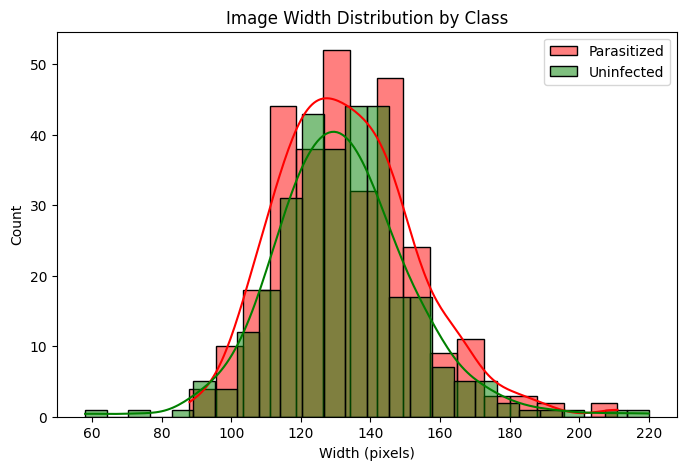

Parasitized mean width: 133.41
Uninfected mean width: 132.11


In [12]:
# Cell 17: Compare image width and height distributions between classes
def get_dims(filepath):
    img = plt.imread(filepath)
    return img.shape[0], img.shape[1]

dims_parasitized = [get_dims(f) for f in sample_parasitized]
dims_uninfected = [get_dims(f) for f in sample_uninfected]

widths_p = [d[1] for d in dims_parasitized]
widths_u = [d[1] for d in dims_uninfected]

plt.figure(figsize=(8, 5))
sns.histplot(widths_p, color="red", label="Parasitized", kde=True, alpha=0.5)
sns.histplot(widths_u, color="green", label="Uninfected", kde=True, alpha=0.5)
plt.title("Image Width Distribution by Class")
plt.xlabel("Width (pixels)")
plt.legend()
plt.show()

print("Parasitized mean width:", np.mean(widths_p))
print("Uninfected mean width:", np.mean(widths_u))